In [1]:
# =============================================================================
# PROYECTO: Análisis de E-Commerce (Olist)
# OBJETIVO: Evaluar KPIs de ventas, tiempos de entrega y satisfacción del cliente
# HERRAMIENTAS: Python (Numpy, Pandas, Matplotlib, Seaborn)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración para que los gráficos se vean elegantes
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [11]:
# Carga de datasets
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')

# Unión de tablas
# Unimos órdenes con sus items para saber qué se vendió y a qué precio
df_final = pd.merge(orders, items, on='order_id', how='inner')

# Unimos con productos para saber la categoría
df_final = pd.merge(df_final, products, on='product_id', how='inner')

print(f"Dataset con {df_final.shape[0]} filas y {df_final.shape[1]} columnas.")

Dataset con 112650 filas y 22 columnas.


In [12]:
# Convertir columnas de fecha a formato datetime
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_columns:
    df_final[col] = pd.to_datetime(df_final[col])

# Verificar el cambio
df_final.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              float64
product_photos_qty                      float64
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       

In [13]:
# Verificar los valores nulos de las columnas
df_final.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
dtype: int64

In [14]:
# Filtramos solo pedidos entregados
df_clean = df_final[df_final['order_status'] == 'delivered'].copy()

# Si faltan nombres de categorías, los llenamos
df_clean['product_category_name'] = df_clean['product_category_name'].fillna('not_defined')

In [15]:
# Creación de métricas
# 1. Tiempo de entrega real en días
df_clean['delivery_time_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_purchase_timestamp']).dt.days

# 2. Diferencia contra la promesa de entrega
df_clean['delivery_delta_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_estimated_delivery_date']).dt.days

# 3. Extraer Mes y Año para ver tendencias (Ventas mensuales)
df_clean['order_month_year'] = df_clean['order_purchase_timestamp'].dt.to_period('M')

# Verificar datos numéricos
df_clean[['delivery_time_days', 'price']].describe()

,delivery_time_days,price
count,110189.000000,110197.000000
mean,12.007342,119.980563
std,9.451153,182.299446
min,0.000000,0.850000
25%,6.000000,39.900000
50%,10.000000,74.900000
75%,15.000000,134.170000
max,209.000000,6735.000000


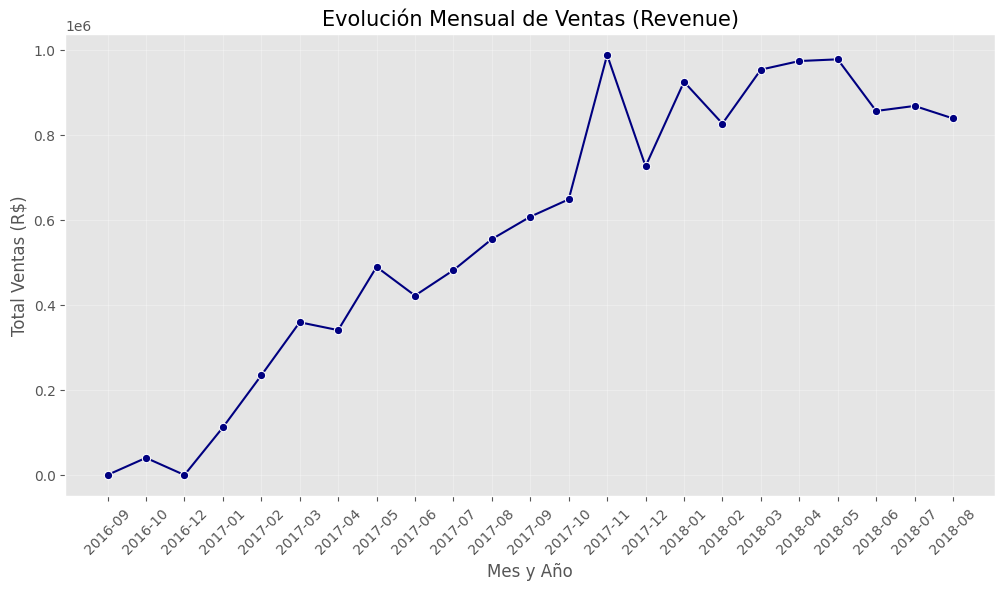

In [16]:
# Agrupamos por mes y sumamos el precio (Ingresos)
monthly_revenue = df_clean.groupby('order_month_year')['price'].sum().reset_index()
monthly_revenue['order_month_year'] = monthly_revenue['order_month_year'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='order_month_year', y='price', marker='o', color='navy')
plt.xticks(rotation=45)
plt.title('Evolución Mensual de Ventas (Revenue)', fontsize=15)
plt.xlabel('Mes y Año')
plt.ylabel('Total Ventas (R$)')
plt.grid(True, alpha=0.3)
plt.show()

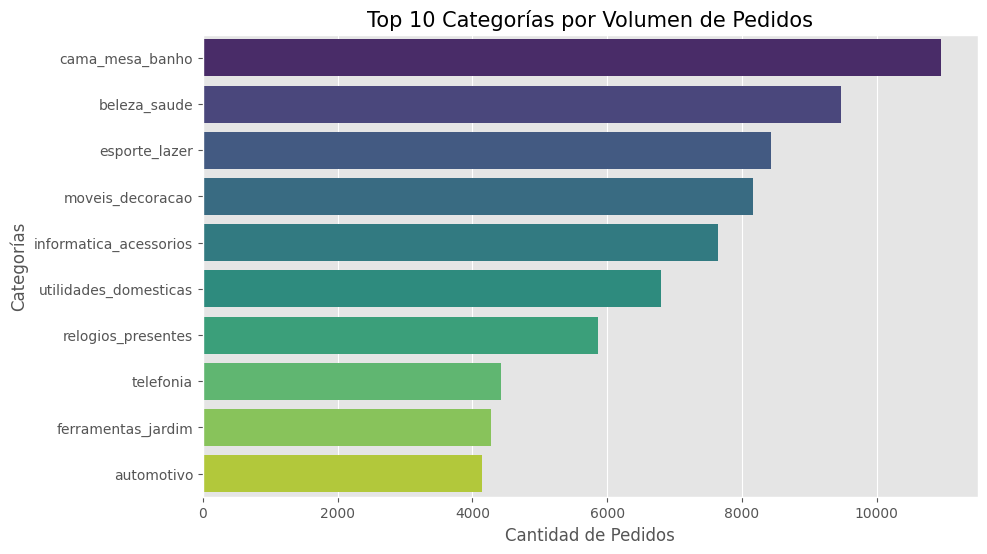

In [22]:
top_categories = df_clean['product_category_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis')
plt.title('Top 10 Categorías por Volumen de Pedidos', fontsize=15)
plt.xlabel('Cantidad de Pedidos')
plt.ylabel('Categorías')
plt.show()

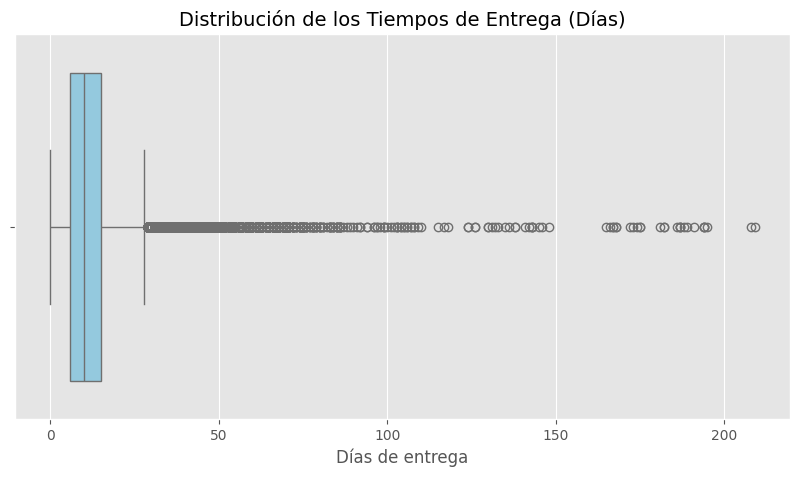

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['delivery_time_days'], color='skyblue')
plt.title('Distribución de los Tiempos de Entrega (Días)', fontsize=15)
plt.xlabel('Días de entrega')
plt.show()

In [23]:
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
df_clean = pd.merge(df_clean, reviews[['order_id', 'review_score']], on='order_id', how='left')

# Calculamos la correlación entre demora y puntaje
correlacion = df_clean[['delivery_time_days', 'review_score', 'price']].corr()
print(correlacion)

                    delivery_time_days  review_score     price
delivery_time_days            1.000000     -0.304013  0.062245
review_score                 -0.304013      1.000000  0.003275
price                         0.062245      0.003275  1.000000


In [24]:
# --- CONCLUSIONES DEL ANÁLISIS ---
print(f"1. El tiempo promedio de entrega es de {df_clean['delivery_time_days'].mean():.2f} días.")
print(f"2. Correlación Demora vs Satisfacción: {df_clean['delivery_time_days'].corr(df_clean['review_score']):.4f}")
print("   *Nota: Existe una relación inversa, a mayor demora, menor satisfacción del cliente.*")

1. El tiempo promedio de entrega es de 12.01 días.
2. Correlación Demora vs Satisfacción: -0.3040
   *Nota: Existe una relación inversa, a mayor demora, menor satisfacción del cliente.*
